# Projeto de Detecção de Incêndio com Validação Cruzada

In [1]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

In [2]:
# Carregando base
base = pd.read_csv('/content/Cientista de dados M35 - smoke_detection_iot.csv')

In [3]:
# Visualizando base
base

,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,0,1654733331,20.000,57.36,0,400,12306,18520,939.735,0.00,0.00,0.00,0.000,0.000,0,0
1,1,1654733332,20.015,56.67,0,400,12345,18651,939.744,0.00,0.00,0.00,0.000,0.000,1,0
2,2,1654733333,20.029,55.96,0,400,12374,18764,939.738,0.00,0.00,0.00,0.000,0.000,2,0
3,3,1654733334,20.044,55.28,0,400,12390,18849,939.736,0.00,0.00,0.00,0.000,0.000,3,0
4,4,1654733335,20.059,54.69,0,400,12403,18921,939.744,0.00,0.00,0.00,0.000,0.000,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62625,62625,1655130047,18.438,15.79,625,400,13723,20569,936.670,0.63,0.65,4.32,0.673,0.015,5739,0
62626,62626,1655130048,18.653,15.87,612,400,13731,20588,936.678,0.61,0.63,4.18,0.652,0.015,5740,0
62627,62627,1655130049,18.867,15.84,627,400,13725,20582,936.687,0.57,0.60,3.95,0.617,0.014,5741,0
62628,62628,1655130050,19.083,16.04,638,400,13712,20566,936.680,0.57,0.59,3.92,0.611,0.014,5742,0


In [4]:
# Renomeando variavel Target
base.rename(columns={'Fire Alarm': 'Fire_Alarm'}, inplace=True)

In [5]:
# Verificando tipo de dados
base.dtypes

,0
Unnamed: 0,int64
UTC,int64
Temperature[C],float64
Humidity[%],float64
TVOC[ppb],int64
eCO2[ppm],int64
Raw H2,int64
Raw Ethanol,int64
Pressure[hPa],float64
PM1.0,float64


In [6]:
# Verificando dados ausentes
base.isnull().sum()

,0
Unnamed: 0,0
UTC,0
Temperature[C],0
Humidity[%],0
TVOC[ppb],0
eCO2[ppm],0
Raw H2,0
Raw Ethanol,0
Pressure[hPa],0
PM1.0,0


In [7]:
# Verificando Outliers
base.describe()

,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire_Alarm
count,62630.000000,6.263000e+04,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000
mean,31314.500000,1.654792e+09,15.970424,48.539499,1942.057528,670.021044,12942.453936,19754.257912,938.627649,100.594309,184.467770,491.463608,203.586487,80.049042,10511.386157,0.714626
std,18079.868017,1.100025e+05,14.359576,8.865367,7811.589055,1905.885439,272.464305,609.513156,1.331344,922.524245,1976.305615,4265.661251,2214.738556,1083.383189,7597.870997,0.451596
min,0.000000,1.654712e+09,-22.010000,10.740000,0.000000,400.000000,10668.000000,15317.000000,930.852000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15657.250000,1.654743e+09,10.994250,47.530000,130.000000,400.000000,12830.000000,19435.000000,938.700000,1.280000,1.340000,8.820000,1.384000,0.033000,3625.250000,0.000000
50%,31314.500000,1.654762e+09,20.130000,50.150000,981.000000,400.000000,12924.000000,19501.000000,938.816000,1.810000,1.880000,12.450000,1.943000,0.044000,9336.000000,1.000000
75%,46971.750000,1.654778e+09,25.409500,53.240000,1189.000000,438.000000,13109.000000,20078.000000,939.418000,2.090000,2.180000,14.420000,2.249000,0.051000,17164.750000,1.000000
max,62629.000000,1.655130e+09,59.930000,75.200000,60000.000000,60000.000000,13803.000000,21410.000000,939.861000,14333.690000,45432.260000,61482.030000,51914.680000,30026.438000,24993.000000,1.000000


**Já podemos analisar possiveis Outliers em:**

Unnamed: 0,
Temperature[C],
Humidity[%],
TVOC[ppb]

In [8]:
import plotly.express as px

# Verificando variavel Unnamed:0

base_nao_zero = base[base['Unnamed: 0']  != 0]

fig = px.box(base_nao_zero, y='Unnamed: 0', title='Box Plot da Unnamed: 0 (Valores Diferentes de Zero)', labels={'Unnamed: 0': 'Valores'})
fig.show()

Não tem presença de Outlier nesta variavel.

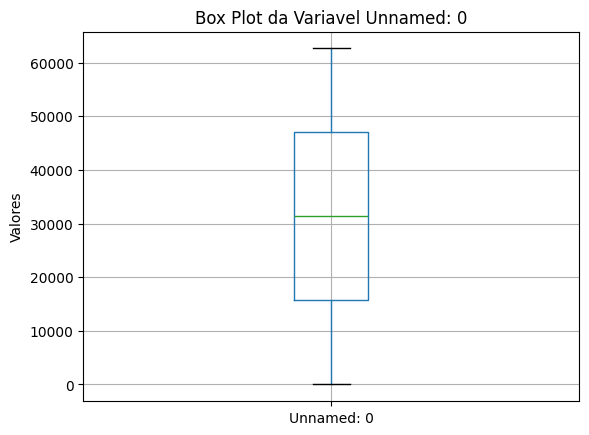

In [9]:
import matplotlib.pyplot as plt

# Criação de Box Plot
base.boxplot(column='Unnamed: 0')
plt.title('Box Plot da Variavel Unnamed: 0')
plt.ylabel('Valores')
plt.show()

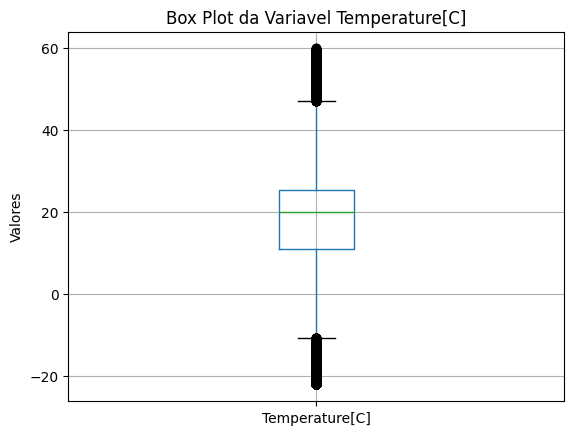

In [10]:
import matplotlib.pyplot as plt

# Criação de Box Plot
base.boxplot(column='Temperature[C]')
plt.title('Box Plot da Variavel Temperature[C]')
plt.ylabel('Valores')
plt.show()

Aqui percebemos a presença de Outliers.

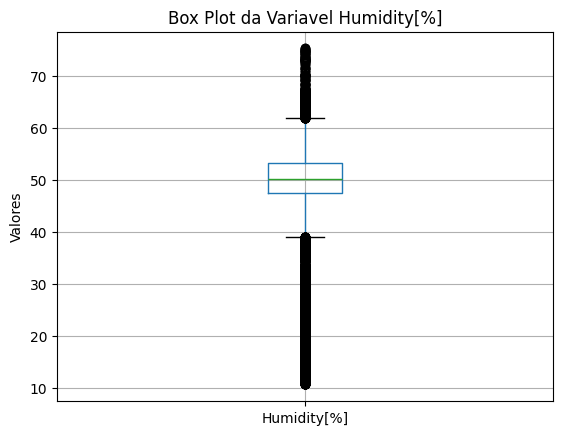

In [11]:
import matplotlib.pyplot as plt

# Criação de Box Plot
base.boxplot(column='Humidity[%]')
plt.title('Box Plot da Variavel Humidity[%]')
plt.ylabel('Valores')
plt.show()

Aqui percebemos a presença de Outliers.

In [12]:
# Verificando base 'Humidity[%]' > 50
base[base['Humidity[%]'] > 50]

,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire_Alarm
0,0,1654733331,20.000,57.36,0,400,12306,18520,939.735,0.00,0.00,0.00,0.000,0.000,0,0
1,1,1654733332,20.015,56.67,0,400,12345,18651,939.744,0.00,0.00,0.00,0.000,0.000,1,0
2,2,1654733333,20.029,55.96,0,400,12374,18764,939.738,0.00,0.00,0.00,0.000,0.000,2,0
3,3,1654733334,20.044,55.28,0,400,12390,18849,939.736,0.00,0.00,0.00,0.000,0.000,3,0
4,4,1654733335,20.059,54.69,0,400,12403,18921,939.744,0.00,0.00,0.00,0.000,0.000,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61035,61035,1655128457,18.497,50.67,6508,400,13095,19553,936.897,0.28,0.29,1.91,0.297,0.007,4149,0
61036,61036,1655128458,18.515,50.48,6524,400,13080,19542,936.893,0.32,0.34,2.22,0.347,0.008,4150,0
61037,61037,1655128459,18.532,50.15,6185,400,13088,19558,936.891,0.33,0.35,2.30,0.358,0.008,4151,0
61038,61038,1655128460,18.550,50.03,6162,400,13099,19568,936.892,0.35,0.37,2.43,0.379,0.009,4152,0


In [13]:
# Verificando base 'Humidity[%]' < 50
base[base['Humidity[%]'] < 50]

,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire_Alarm
22,22,1654733353,20.320,49.96,0,400,12492,19489,939.756,0.31,1.30,0.00,1.497,0.953,22,0
23,23,1654733354,20.334,49.83,0,415,12495,19489,939.764,0.27,1.12,0.00,1.291,0.821,23,0
24,24,1654733355,20.348,49.76,0,400,12498,19503,939.770,0.25,1.04,0.00,1.197,0.762,24,0
25,25,1654733356,20.363,49.65,0,401,12499,19516,939.774,0.21,0.89,0.00,1.026,0.653,25,0
26,26,1654733357,20.377,49.58,0,404,12503,19525,939.771,0.20,0.82,0.00,0.949,0.604,26,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62625,62625,1655130047,18.438,15.79,625,400,13723,20569,936.670,0.63,0.65,4.32,0.673,0.015,5739,0
62626,62626,1655130048,18.653,15.87,612,400,13731,20588,936.678,0.61,0.63,4.18,0.652,0.015,5740,0
62627,62627,1655130049,18.867,15.84,627,400,13725,20582,936.687,0.57,0.60,3.95,0.617,0.014,5741,0
62628,62628,1655130050,19.083,16.04,638,400,13712,20566,936.680,0.57,0.59,3.92,0.611,0.014,5742,0


In [14]:
# Verificando Porcentagem do Humidity[%] > 50
print("Porcentagem de registros onde 'Humidity[%]' > 5900:",
      (len(base[base['Humidity[%]'] > 50]) / len(base)) * 100)

Porcentagem de registros onde 'Humidity[%]' > 5900: 51.12086859332589


In [15]:
# Verificando Porcentagem do Humidity[%] < 50
print("Porcentagem de registros onde 'Humidity[%]' > 5900:",
      (len(base[base['Humidity[%]'] < 50]) / len(base)) * 100)

Porcentagem de registros onde 'Humidity[%]' > 5900: 48.78013731438608


Como essa variavel equivale a boa parte da nossa base e parece dados reais, então decidimos que vamos manter a variavel.

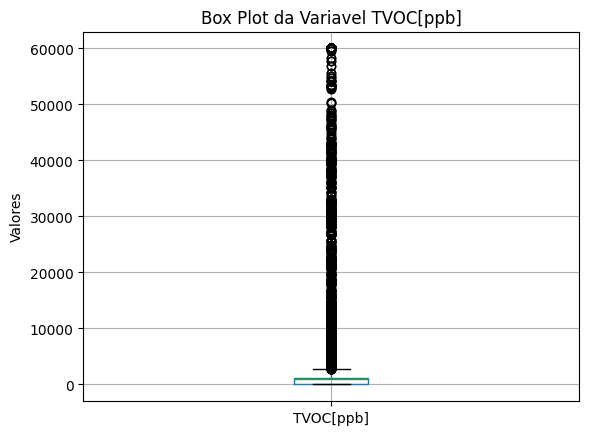

In [16]:
import matplotlib.pyplot as plt

# Criação de Box Plot
base.boxplot(column='TVOC[ppb]')
plt.title('Box Plot da Variavel TVOC[ppb]')
plt.ylabel('Valores')
plt.show()

Aqui percebemos a presença de Outliers.

In [17]:
# Verificando base 'TVOC[ppb]' > 0
base[base['TVOC[ppb]'] > 0]

,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire_Alarm
27,27,1654733358,20.391,49.37,30,445,12478,19500,939.771,0.17,0.58,0.14,0.665,0.398,27,0
28,28,1654733359,20.406,49.58,36,455,12472,19487,939.770,0.16,0.56,0.13,0.644,0.385,28,0
29,29,1654733360,20.420,50.11,20,443,12471,19493,939.775,0.15,0.52,0.12,0.595,0.356,29,0
30,30,1654733361,20.434,50.68,16,435,12481,19509,939.772,0.14,0.50,0.12,0.569,0.340,30,0
31,31,1654733362,20.448,51.23,8,440,12482,19520,939.772,0.13,0.45,0.11,0.514,0.308,31,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62625,62625,1655130047,18.438,15.79,625,400,13723,20569,936.670,0.63,0.65,4.32,0.673,0.015,5739,0
62626,62626,1655130048,18.653,15.87,612,400,13731,20588,936.678,0.61,0.63,4.18,0.652,0.015,5740,0
62627,62627,1655130049,18.867,15.84,627,400,13725,20582,936.687,0.57,0.60,3.95,0.617,0.014,5741,0
62628,62628,1655130050,19.083,16.04,638,400,13712,20566,936.680,0.57,0.59,3.92,0.611,0.014,5742,0


In [18]:
# Verificando Porcentagem do TVOC[ppb] > 0
print("Porcentagem de registros onde 'TVOC[ppb]' > 0:",
      (len(base[base['TVOC[ppb]'] > 0]) / len(base)) * 100)

Porcentagem de registros onde 'TVOC[ppb]' > 0: 95.69216030656234


Como essa variavel equivale a 95% da nossa base e parece dados reais, então decidimos que vamos manter a variavel.

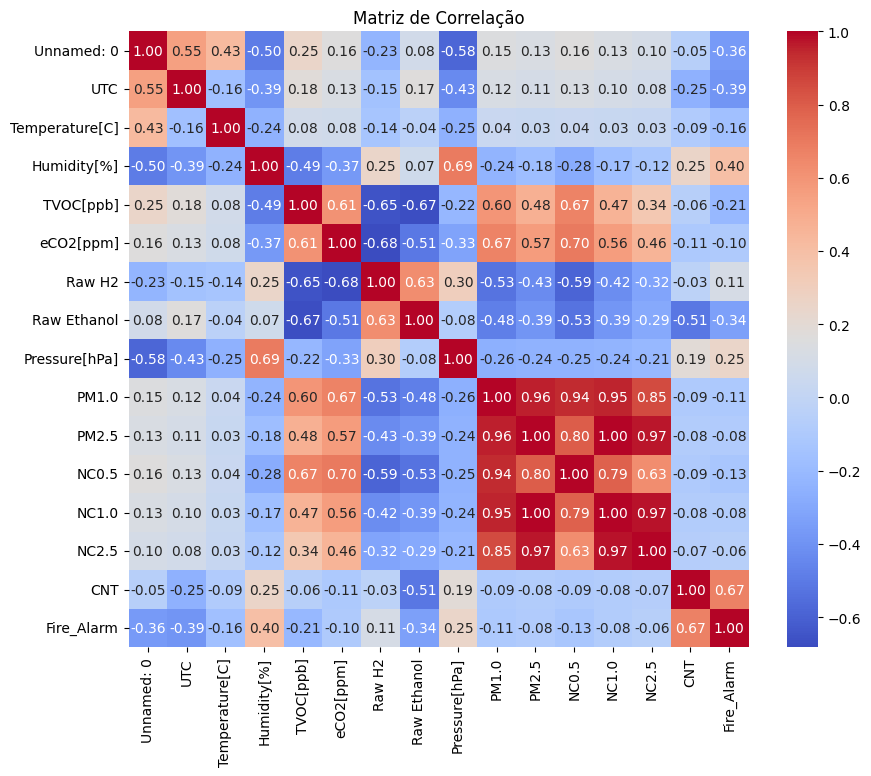

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotando grafico da matriz
correlation_matrix = base.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

**A Matrix da Correlação nos permite visualizar que:**

**Altas Correlações Positivas com 'Fire_Alarm':** Podemos observar que as variáveis relacionadas à detecção de fumaça e produtos de combustão, como TVOC[ppb], eCO2[ppm], Raw H2, Raw Ethanol, PM1.0, PM2.5, NC0.5, NC1.0 e NC2.5, apresentam fortes correlações positivas com a 'Fire_Alarm'. Isso é esperado, pois um aumento nesses compostos e partículas é um forte indicador de incêndio.

**Correlação Positiva Moderada com Temperatura:** A Temperature[C] também demonstra uma correlação positiva com 'Fire_Alarm', o que é lógico, já que um incêndio eleva a temperatura.
Correlação Negativa Moderada com Umidade: A Humidity[%] tende a ter uma correlação negativa, sugerindo que níveis mais baixos de umidade podem estar associados a uma maior probabilidade de incêndio, ou que a umidade diminui durante um incêndio.

**Correlações Irrelevantes:** As variáveis Unnamed: 0, UTC e CNT têm correlações muito baixas com 'Fire_Alarm', o que indica que não são preditores importantes para a ocorrência de incêndios. Unnamed: 0 e CNT são índices ou contadores e são irrelevantes para o modelo. UTC representa o tempo e sua baixa correlação pode indicar que a ocorrência de incêndios não tem uma forte dependência direta do carimbo de tempo bruto, mas sim das condições ambientais naquele momento.

**Em resumo, as variáveis mais promissoras para prever 'Fire_Alarm' são aquelas relacionadas diretamente com fumaça, gases e partículas liberados durante a combustão, juntamente com a temperatura. A umidade também pode ser um fator relevante. As variáveis Unnamed: 0, UTC e CNT provavelmente podem ser descartadas ou ter seu impacto reavaliado para simplificar o modelo.**

**A escolha da Regressão Logística para esta análise é tecnicamente justificada por diversos motivos, que se alinham à natureza dos seus dados e ao objetivo do modelo:**

**Natureza da Variável Alvo:** A variável dependente, 'Fire_Alarm', é de natureza binária, assumindo valores discretos (0 ou 1). A Regressão Logística é um modelo preditivo intrinsecamente projetado para lidar com resultados dicotômicos, estimando a probabilidade de ocorrência de uma das duas classes.

**Modelagem de Probabilidades:** Diferentemente de modelos de classificação que retornam apenas a classe prevista, a Regressão Logística modela diretamente a probabilidade de um evento. Esta capacidade é crucial quando se deseja não apenas prever a ocorrência de um incêndio, mas também quantificar a confiança ou a probabilidade associada a essa previsão.

**Interpretabilidade:** A Regressão Logística, sendo um modelo linear generalizado, oferece boa interpretabilidade dos coeficientes. Isso permite compreender a magnitude e a direção da influência de cada variável preditora na probabilidade de 'Fire_Alarm'.

**Eficiência e Robustez:** É um algoritmo computacionalmente eficiente e relativamente robusto a violações de algumas suposições, como a normalidade dos preditores (embora a linearidade na relação com o log-odds seja importante).

**A Regressão Logística é a escolha metodológica mais adequada para este contexto, pois alinha-se perfeitamente à estrutura binária da sua variável resposta e aos requisitos de interpretabilidade e probabilidade do problema de detecção de incêndios.**

In [20]:
# Separando base
X = base.drop('Fire_Alarm', axis=1)
y = base['Fire_Alarm']

In [21]:
# Instanciando o modelo de regressão logística
modelo = LogisticRegression(max_iter=1000)

In [22]:
# Determinando o numero de folds
folds = 5

In [23]:
# Configurando o Cross Validation
crossvalidation = KFold(n_splits=folds, shuffle=True, random_state=5)

In [24]:
modelo = LogisticRegression(max_iter=1000)
modelo_final = cross_val_score(modelo, X, y, cv = folds)

In [25]:
# Avaliando a pontuação de cada modelo
pontuacoes = cross_val_score(modelo, X, y, cv=crossvalidation)

print(f"Pontuações por fold: {pontuacoes}")

Pontuações por fold: [0.97612965 0.97581031 0.98826441 0.98642823 0.97684816]


In [26]:
# Validando media final do modelo
print((modelo_final.mean()))

0.9207408590132523
